<a href="https://colab.research.google.com/github/Nish613/OlympicMedals_MLPrediction/blob/ML-model/OlympicMedals_MLPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [57]:
teams = pd.read_csv("teams.csv")
teams

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,19,26,25.0,179.0,71.1,0,0.0,0.0
2140,ZIM,Zimbabwe,2004,11,14,25.1,177.8,70.5,3,0.0,0.0
2141,ZIM,Zimbabwe,2008,15,16,26.1,171.9,63.7,4,3.0,1.0
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0,4.0,2.3


In [58]:
teams = teams[["team","country","year","athletes","age","prev_medals","medals"]]
teams.head()

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0


In [59]:
teams.corr(numeric_only=True)["medals"] #trying to find correlation between medals and other attributes

,medals
year,-0.021603
athletes,0.840817
age,0.025096
prev_medals,0.920048
medals,1.000000


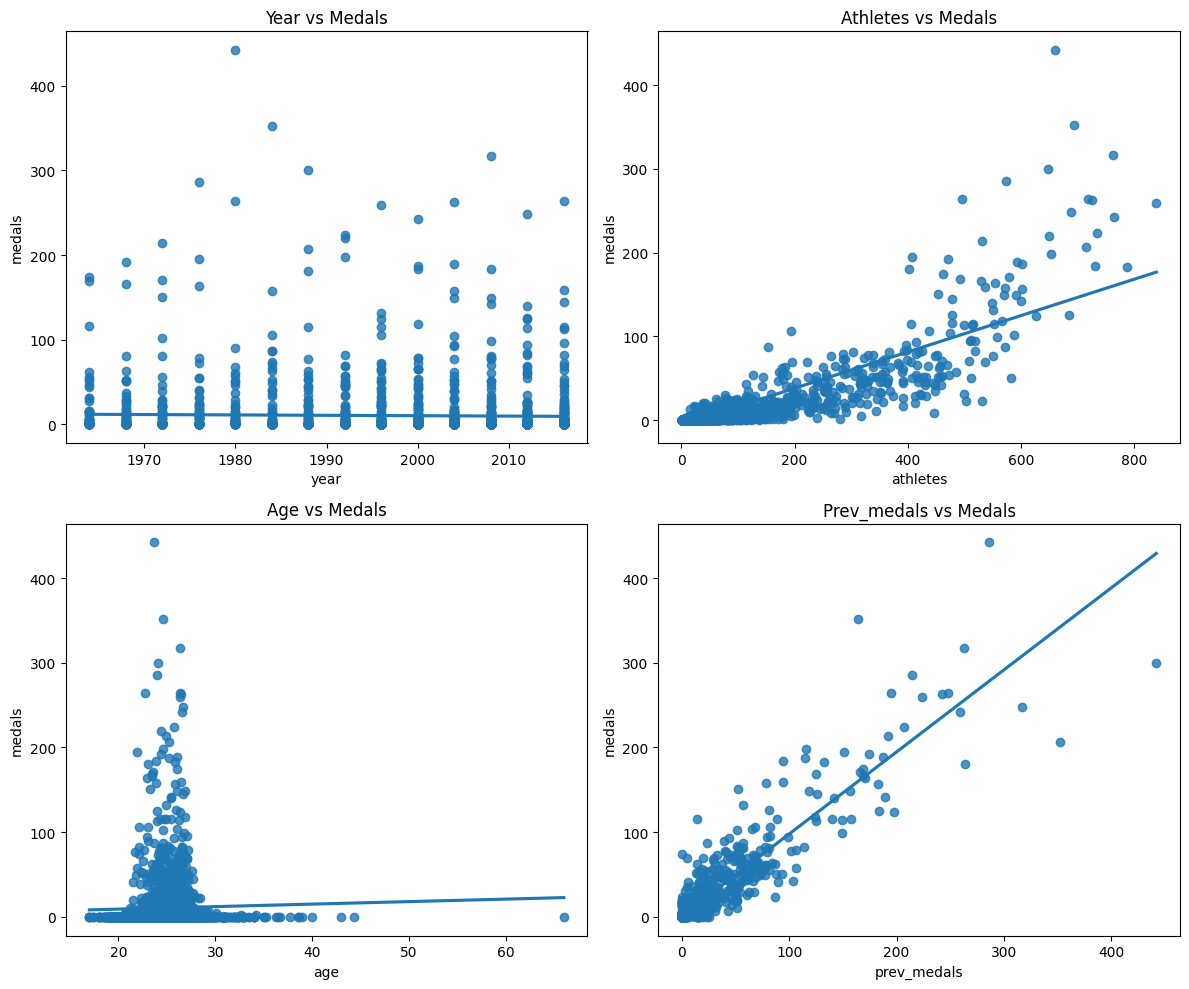

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.regplot(x="year", y="medals", data=teams, ci=None, ax=axes[0, 0])
axes[0, 0].set_title("Year vs Medals")

sns.regplot(x="athletes", y="medals", data=teams, ci=None, ax=axes[0, 1])
axes[0, 1].set_title("Athletes vs Medals")

sns.regplot(x="age", y="medals", data=teams, ci=None, ax=axes[1, 0])
axes[1, 0].set_title("Age vs Medals")

sns.regplot(x="prev_medals", y="medals", data=teams, ci=None, ax=axes[1, 1])
axes[1, 1].set_title("Prev_medals vs Medals")

plt.tight_layout()
plt.show()

<Axes: ylabel='Frequency'>

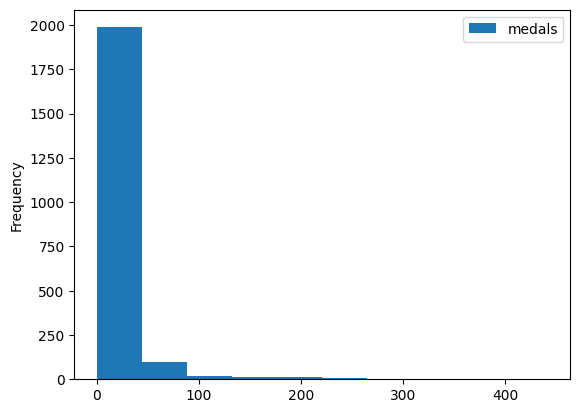

In [61]:
teams.plot.hist(y="medals")

In [62]:
teams[teams.isnull().any(axis=1)].head()


,team,country,year,athletes,age,prev_medals,medals
19,ALB,Albania,1992,9,25.3,NaN,0
26,ALG,Algeria,1964,7,26.0,NaN,0
39,AND,Andorra,1976,3,28.3,NaN,0
50,ANG,Angola,1980,17,17.4,NaN,0
59,ANT,Antigua and Barbuda,1976,17,23.2,NaN,0


In [63]:
teams=teams.dropna()
teams

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0
...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,25.0,0.0,0
2140,ZIM,Zimbabwe,2004,14,25.1,0.0,3
2141,ZIM,Zimbabwe,2008,16,26.1,3.0,4
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0


In [64]:
train = teams[teams["year"]<2012].copy()
test = teams[teams["year"]>=2012].copy()
print("Training dataset shape : ",train.shape)
print("Testing dataset shape : ",test.shape)

Training dataset shape :  (1609, 7)
Testing dataset shape :  (405, 7)


In [65]:
reg = LinearRegression()
predictors = ["athletes","prev_medals"]
target = "medals"

In [66]:
reg.fit(train[predictors],train[target])

LinearRegression()

In [67]:
predictions = reg.predict(test[predictors])

In [68]:
test["predictions"] = predictions
test.head()

,team,country,year,athletes,age,prev_medals,medals,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,-0.961221
7,AFG,Afghanistan,2016,3,24.7,1.0,0,-1.176333
24,ALB,Albania,2012,10,25.7,0.0,0,-1.425032
25,ALB,Albania,2016,6,23.7,0.0,0,-1.711847
37,ALG,Algeria,2012,39,24.8,2.0,1,2.155629


In [69]:
test.loc[test["predictions"]<0,"predictions"] = 0
test["predictions"] = test["predictions"].round()
test.head()

,team,country,year,athletes,age,prev_medals,medals,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,0.0
7,AFG,Afghanistan,2016,3,24.7,1.0,0,0.0
24,ALB,Albania,2012,10,25.7,0.0,0,0.0
25,ALB,Albania,2016,6,23.7,0.0,0,0.0
37,ALG,Algeria,2012,39,24.8,2.0,1,2.0


In [70]:
error = mean_absolute_error(test["medals"],test["predictions"])
error

3.2987654320987656

In [71]:
teams.describe()["medals"] #make sure error is below std if its not predictors are not useful or model is wrong

,medals
count,2014.000000
mean,10.990070
std,33.627528
min,0.000000
25%,0.000000
50%,0.000000
75%,5.000000
max,442.000000
